In [49]:
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

In [50]:
df=sns.load_dataset('iris')

In [51]:
print(df.shape)
df.head()

(150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [52]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [53]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [54]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [55]:
encoder=LabelEncoder()
df['species']=encoder.fit_transform(df['species'])

In [56]:
df = df[['sepal_length','petal_length','species']]

In [57]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [58]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

# Softmax regression
one model with m,any coefficents

In [59]:
clf1=LogisticRegression(multi_class='multinomial')
clf1.fit(X_train,y_train)
y_pred=clf1.predict(X_test)

C:\Users\Strange\anaconda3\envs\ml310\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [60]:
print(accuracy_score(y_test,y_pred))

0.9666666666666667


In [61]:
# prediction
query = np.array([[3.4,2.7]])
clf1.predict_proba(query)

C:\Users\Strange\anaconda3\envs\ml310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[7.25865651e-01, 2.73720718e-01, 4.13631316e-04]])

In [62]:
clf1.predict(query)

C:\Users\Strange\anaconda3\envs\ml310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

C:\Users\Strange\anaconda3\envs\ml310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


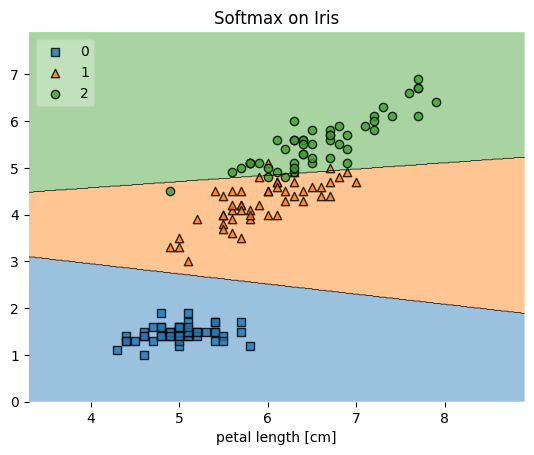

In [63]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X.values, y.values, clf1, legend=2)

# Adding axes annotations
plt.xlabel('sepal length [cm]')
plt.xlabel('petal length [cm]')
plt.title('Softmax on Iris')

plt.show()

# one vs Rest
-for every class one model is trained 

In [67]:
clf2=LogisticRegression(multi_class='ovr')

In [68]:
clf2.fit(X_train,y_train)
y_pred2=clf2.predict(X_test)

C:\Users\Strange\anaconda3\envs\ml310\lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [71]:
print(accuracy_score(y_pred,y_test))

0.9666666666666667


In [73]:
querry=np.array([[3,4]])
clf2.predict_proba(querry)

C:\Users\Strange\anaconda3\envs\ml310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.04330265, 0.84399496, 0.11270239]])

In [74]:
clf2.predict(querry)

C:\Users\Strange\anaconda3\envs\ml310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

In [77]:
from mlxtend.plotting import plot_decision_regions

C:\Users\Strange\anaconda3\envs\ml310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


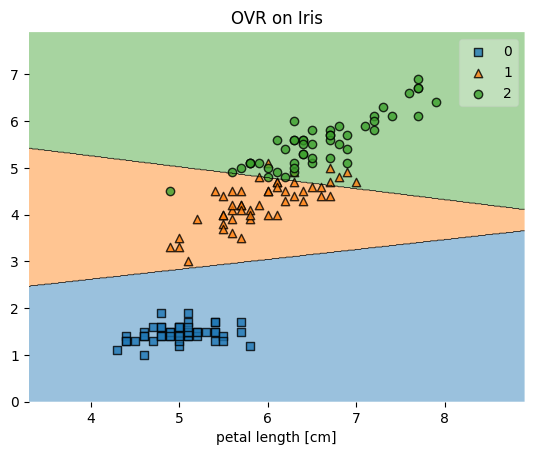

In [84]:
plot_decision_regions(X.values,y.values,clf2,legend=1)
# Adding axes annotations
plt.xlabel('sepal length [cm]')
plt.xlabel('petal length [cm]')
plt.title('OVR on Iris')

plt.show()
